All files loaded
Fund: (40, 15)
NAV: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Folio: (21, 6)
Performance: (40, 19)
Transactions: (32778, 13)
Portfolio: (322, 8)
Benchmark: (8050, 3)
NAV Trend Created
SIP Trend Created
AUM Chart Created
Category Heatmap Created
Investor Demographics Created
Geographic Analysis Created
Folio Growth Created
Sector Allocation Created
NAV Correlation Matrix Created
Benchmark Trend Created


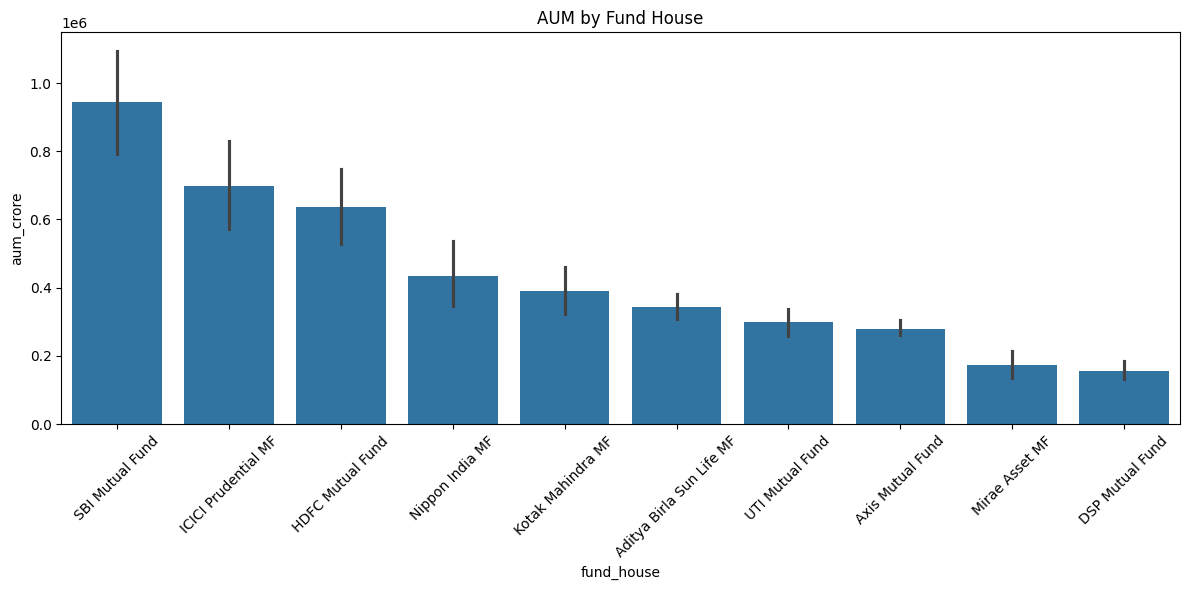

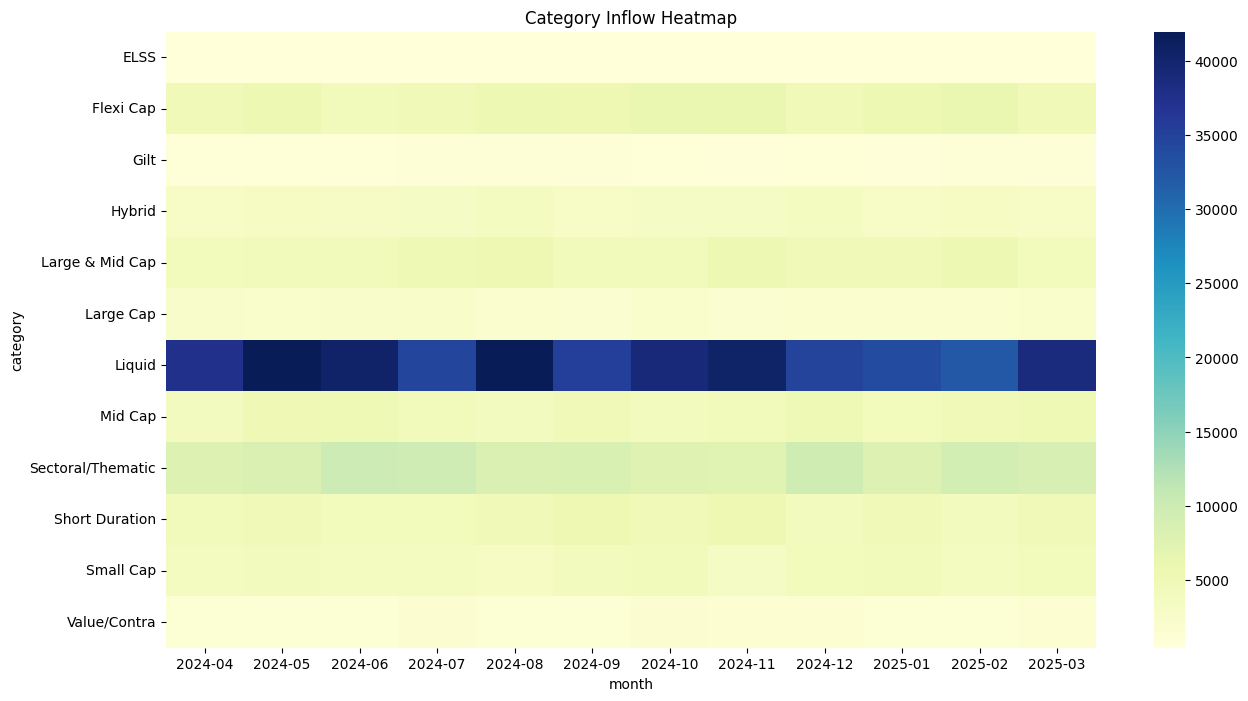

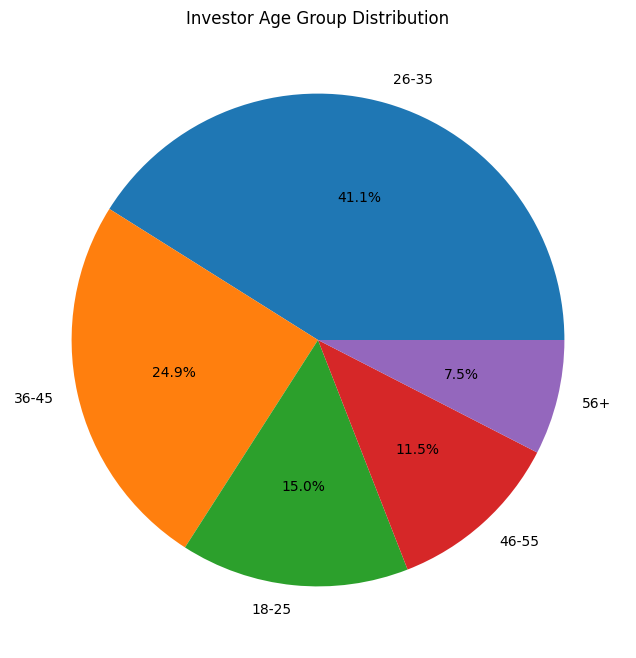

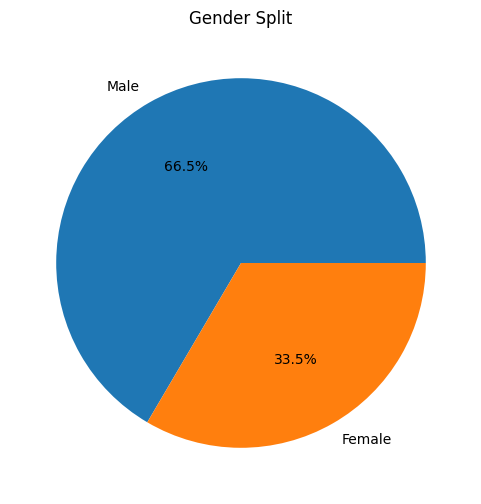

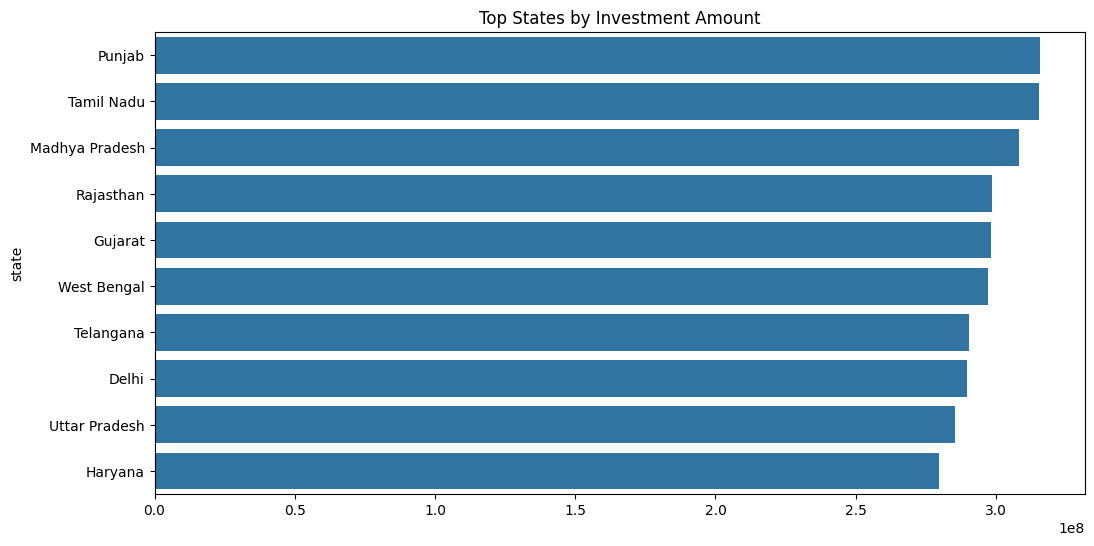

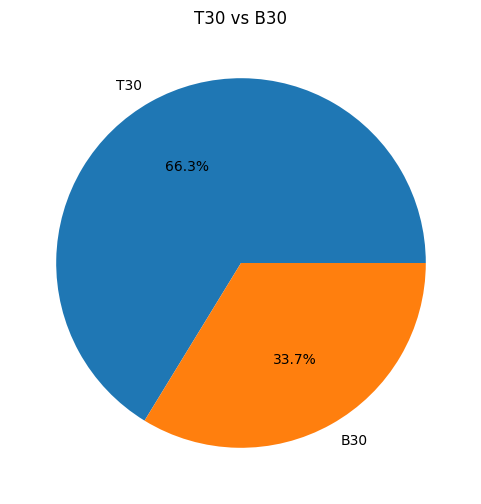

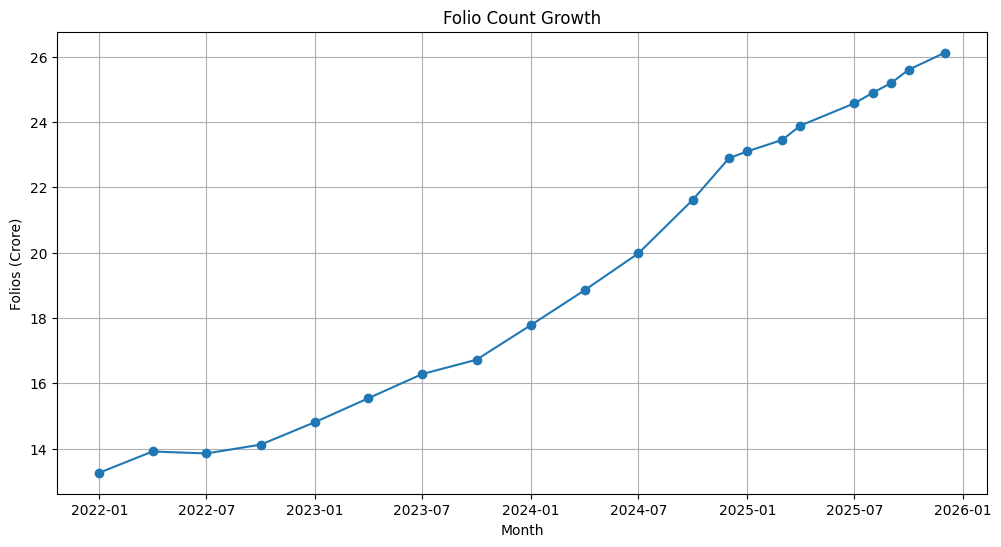

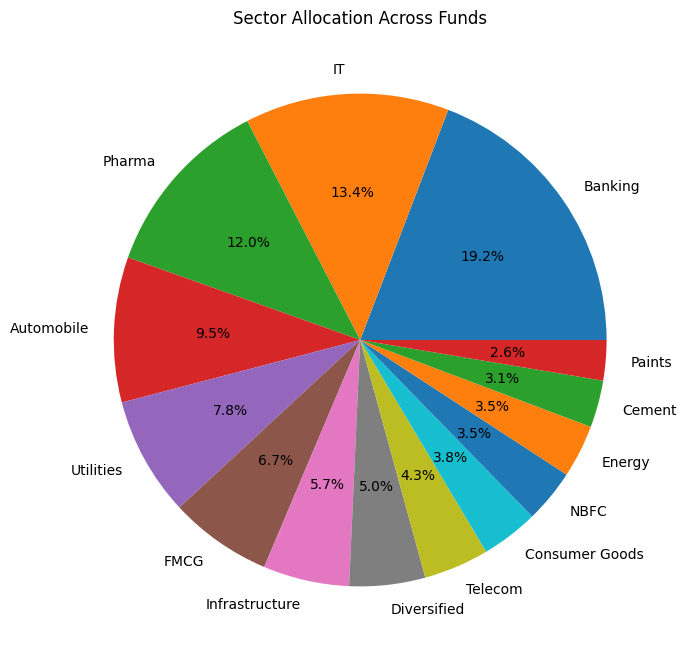

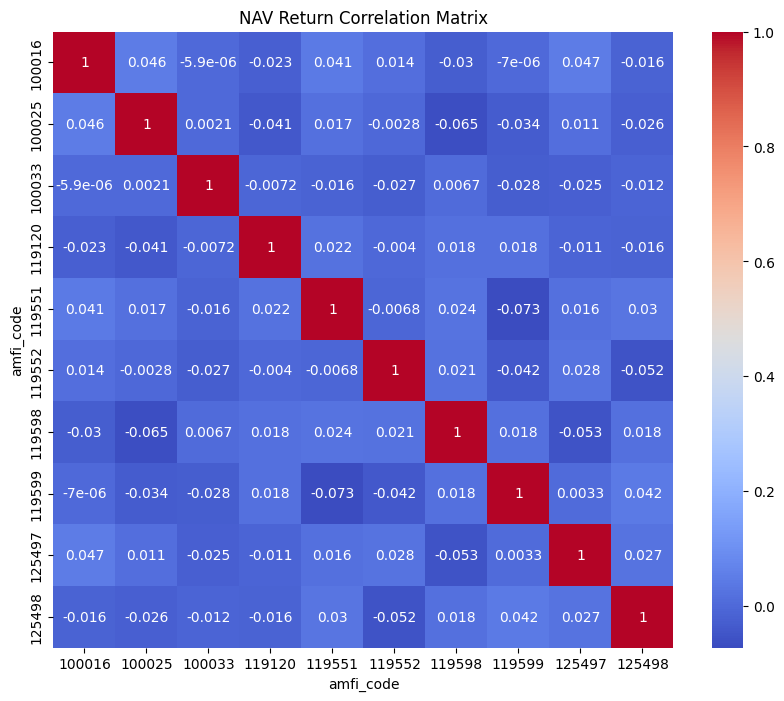

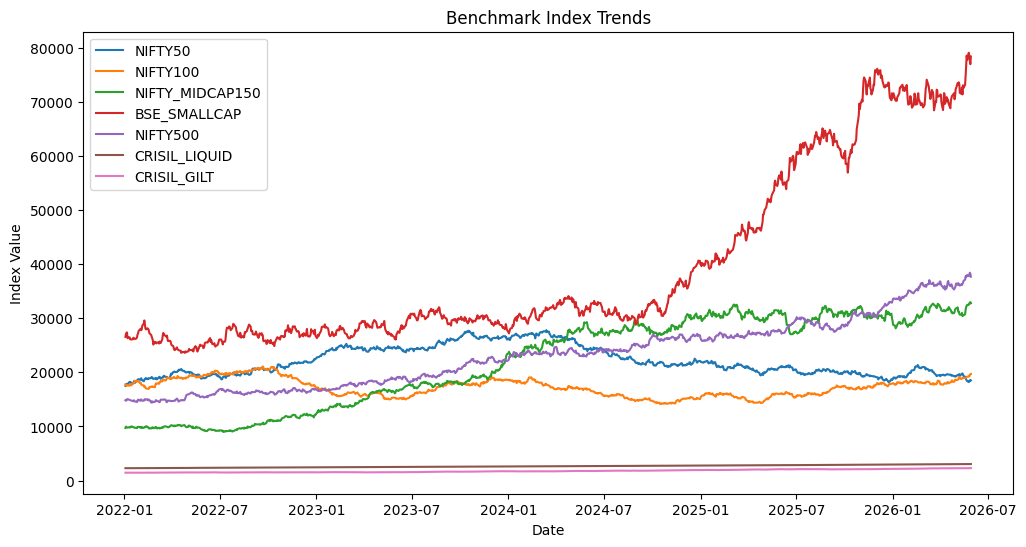

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.rcParams["figure.figsize"] = (12,6)

fund = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
aum = pd.read_csv("../data/processed/03_aum_by_fund_house_cleaned.csv")
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_cleaned.csv")
category = pd.read_csv("../data/processed/05_category_inflows_cleaned.csv")
folio = pd.read_csv("../data/processed/06_industry_folio_count_cleaned.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")
portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv")

print("All files loaded")

print("Fund:", fund.shape)
print("NAV:", nav.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Category:", category.shape)
print("Folio:", folio.shape)
print("Performance:", performance.shape)
print("Transactions:", transactions.shape)
print("Portfolio:", portfolio.shape)
print("Benchmark:", benchmark.shape)
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="NAV Trend Analysis"
)

fig.write_html("../dashboard/nav_trend.html")

print("NAV Trend Created")
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend"
)

fig.write_html("../dashboard/sip_trend.html")

plt.figure(figsize=(12,6))

aum_sorted = aum.sort_values(
    "aum_crore",
    ascending=False
)

sns.barplot(
    data=aum_sorted,
    x="fund_house",
    y="aum_crore"
)

plt.xticks(rotation=45)
plt.title("AUM by Fund House")

plt.tight_layout()

plt.savefig("../dashboard/aum_growth.png")

heatmap_data = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(15,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.savefig("../dashboard/category_heatmap.png")

print("SIP Trend Created")
print("AUM Chart Created")
print("Category Heatmap Created")
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))
plt.pie(age_counts.values, labels=age_counts.index, autopct="%1.1f%%")
plt.title("Investor Age Group Distribution")
plt.savefig("../dashboard/age_distribution.png")

gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(gender_counts.values, labels=gender_counts.index, autopct="%1.1f%%")
plt.title("Gender Split")
plt.savefig("../dashboard/gender_split.png")

state_data = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=state_data.values,
    y=state_data.index
)
plt.title("Top States by Investment Amount")
plt.savefig("../dashboard/state_distribution.png")

tier_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    tier_counts.values,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)
plt.title("T30 vs B30")
plt.savefig("../dashboard/t30_b30.png")

print("Investor Demographics Created")
print("Geographic Analysis Created")
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Folio Count Growth")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")
plt.grid(True)

plt.savefig("../dashboard/folio_growth.png")

print("Folio Growth Created")
sector_data = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%"
)

plt.title("Sector Allocation Across Funds")

plt.savefig("../dashboard/sector_allocation.png")

print("Sector Allocation Created")
# NAV Correlation Matrix

top_funds = nav["amfi_code"].unique()[:10]

nav_subset = nav[nav["amfi_code"].isin(top_funds)]

pivot_nav = nav_subset.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot_nav.pct_change()

corr_matrix = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")

plt.savefig("../dashboard/nav_correlation.png")

print("NAV Correlation Matrix Created")
# Benchmark Trend Analysis

benchmark["date"] = pd.to_datetime(benchmark["date"])

plt.figure(figsize=(12,6))

for index_name in benchmark["index_name"].unique():
    temp = benchmark[benchmark["index_name"] == index_name]

    plt.plot(
        temp["date"],
        temp["close_value"],
        label=index_name
    )

plt.title("Benchmark Index Trends")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.legend()

plt.savefig("../dashboard/benchmark_trend.png")

print("Benchmark Trend Created")